<a href="https://colab.research.google.com/github/simaryadav/learning_roadmap/blob/main/churn_rate_botswana/Botswana_bank_churn_rate_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Data loading and EDA

In [14]:
df = pd.read_csv("botswana_bank_customer_churn.csv")

In [15]:
df

,RowNumber,CustomerId,Surname,First Name,Date of Birth,Gender,Marital Status,Number of Dependents,Occupation,Income,...,Preferred Communication Channel,Credit Score,Credit History Length,Outstanding Loans,Churn Flag,Churn Reason,Churn Date,Balance,NumOfProducts,NumComplaints
0,1,83ef0b54-35f6-4f84-af58-5653ac0c0dc4,Smith,Troy,1987-08-29,Male,Divorced,3,Information systems manager,77710.14,...,Phone,397,24,41959.74,0,NaN,NaN,211359.05,1,0
1,2,009f115a-e5ca-4cf4-97d6-530140545e4e,Sullivan,Katrina,2000-02-07,Female,Married,1,Charity fundraiser,58209.87,...,Email,665,10,8916.67,0,NaN,NaN,30624.76,4,1
2,3,66309fd3-5009-44d3-a3f7-1657c869d573,Fuller,Henry,1954-02-03,Female,Single,1,Television production assistant,9794.01,...,Email,715,21,43270.54,0,NaN,NaN,111956.61,2,6
3,4,b02a30df-1a5f-4087-8075-2a35432da641,Young,Antonio,1991-01-15,Female,Divorced,5,Agricultural engineer,15088.98,...,Phone,747,17,17887.65,0,NaN,NaN,201187.61,1,0
4,5,0d932e5b-bb3a-4104-8c83-f84270f7f2ea,Andersen,John,1992-04-08,Female,Divorced,2,"Teacher, early years/pre",60726.56,...,Email,549,25,32686.84,0,NaN,NaN,60391.24,5,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115635,115636,b4ef7eba-1a9e-4956-b827-50037a1087d5,Russell,Gregory,1965-03-09,Male,Divorced,2,Chemical engineer,15704.15,...,Phone,350,23,26370.30,1,Account Closure,2024-06-24,20804.19,2,7
115636,115637,578e6b99-b42a-4af1-afb4-fd570ea0721f,Ramirez,Thomas,1955-01-10,Female,Single,3,Chartered legal executive (England and Wales),75792.62,...,Email,721,15,36229.64,0,NaN,NaN,10041.21,4,7
115637,115638,73a64c22-da8f-4c3e-8f62-d92f03636a1e,Clark,Tonya,1955-08-29,Male,Married,4,Field trials officer,30142.28,...,Email,773,19,6440.85,0,NaN,NaN,108833.43,1,4
115638,115639,00affc66-75c4-43c4-9019-f28c434b5012,Stewart,Lisa,1992-12-27,Female,Married,0,Legal secretary,58636.06,...,Phone,584,23,5740.08,0,NaN,NaN,195548.32,5,6


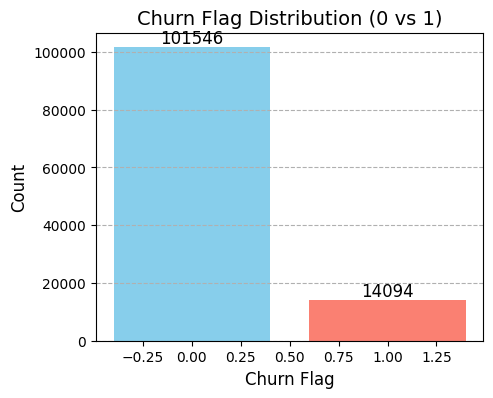

In [17]:
churn_counts = df['Churn Flag'].value_counts()

plt.figure(figsize=(5, 4))
bars = plt.bar(churn_counts.index, churn_counts.values, color=['skyblue', 'salmon'])

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval),
             ha='center', va='bottom', fontsize=12)

plt.title('Churn Flag Distribution (0 vs 1)', fontsize=14)
plt.xlabel('Churn Flag', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--')
plt.show()

In [18]:
df.shape

(115640, 25)

In [19]:
df.head()

,RowNumber,CustomerId,Surname,First Name,Date of Birth,Gender,Marital Status,Number of Dependents,Occupation,Income,...,Preferred Communication Channel,Credit Score,Credit History Length,Outstanding Loans,Churn Flag,Churn Reason,Churn Date,Balance,NumOfProducts,NumComplaints
0,1,83ef0b54-35f6-4f84-af58-5653ac0c0dc4,Smith,Troy,1987-08-29,Male,Divorced,3,Information systems manager,77710.14,...,Phone,397,24,41959.74,0,NaN,NaN,211359.05,1,0
1,2,009f115a-e5ca-4cf4-97d6-530140545e4e,Sullivan,Katrina,2000-02-07,Female,Married,1,Charity fundraiser,58209.87,...,Email,665,10,8916.67,0,NaN,NaN,30624.76,4,1
2,3,66309fd3-5009-44d3-a3f7-1657c869d573,Fuller,Henry,1954-02-03,Female,Single,1,Television production assistant,9794.01,...,Email,715,21,43270.54,0,NaN,NaN,111956.61,2,6
3,4,b02a30df-1a5f-4087-8075-2a35432da641,Young,Antonio,1991-01-15,Female,Divorced,5,Agricultural engineer,15088.98,...,Phone,747,17,17887.65,0,NaN,NaN,201187.61,1,0
4,5,0d932e5b-bb3a-4104-8c83-f84270f7f2ea,Andersen,John,1992-04-08,Female,Divorced,2,"Teacher, early years/pre",60726.56,...,Email,549,25,32686.84,0,NaN,NaN,60391.24,5,6


In [20]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'First Name', 'Date of Birth',
       'Gender', 'Marital Status', 'Number of Dependents', 'Occupation',
       'Income', 'Education Level', 'Address', 'Contact Information',
       'Customer Tenure', 'Customer Segment',
       'Preferred Communication Channel', 'Credit Score',
       'Credit History Length', 'Outstanding Loans', 'Churn Flag',
       'Churn Reason', 'Churn Date', 'Balance', 'NumOfProducts',
       'NumComplaints'],
      dtype='object')

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115640 entries, 0 to 115639
Data columns (total 25 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   RowNumber                        115640 non-null  int64  
 1   CustomerId                       115640 non-null  object 
 2   Surname                          115640 non-null  object 
 3   First Name                       115640 non-null  object 
 4   Date of Birth                    115640 non-null  object 
 5   Gender                           115640 non-null  object 
 6   Marital Status                   115640 non-null  object 
 7   Number of Dependents             115640 non-null  int64  
 8   Occupation                       115640 non-null  object 
 9   Income                           115640 non-null  float64
 10  Education Level                  115640 non-null  object 
 11  Address                          115640 non-null  object 
 12  Co

Unique Values in columns

In [22]:
for col in df.columns:
  print(col, df[col].nunique())

RowNumber 115640
CustomerId 115640
Surname 1000
First Name 690
Date of Birth 21094
Gender 2
Marital Status 3
Number of Dependents 6
Occupation 639
Income 114953
Education Level 4
Address 115640
Contact Information 115640
Customer Tenure 30
Customer Segment 3
Preferred Communication Channel 2
Credit Score 551
Credit History Length 30
Outstanding Loans 114298
Churn Flag 2
Churn Reason 4
Churn Date 220
Balance 115387
NumOfProducts 5
NumComplaints 11


Null Values Present

In [23]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
First Name,0
Date of Birth,0
Gender,0
Marital Status,0
Number of Dependents,0
Occupation,0
Income,0


In [24]:
df['Churn Reason'].fillna('No', inplace=True)
df['Churn Date'].fillna('No', inplace=True)

<ipython-input-24-4ba173e80cdb>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Churn Reason'].fillna('No', inplace=True)
<ipython-input-24-4ba173e80cdb>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using '

In [25]:
df

,RowNumber,CustomerId,Surname,First Name,Date of Birth,Gender,Marital Status,Number of Dependents,Occupation,Income,...,Preferred Communication Channel,Credit Score,Credit History Length,Outstanding Loans,Churn Flag,Churn Reason,Churn Date,Balance,NumOfProducts,NumComplaints
0,1,83ef0b54-35f6-4f84-af58-5653ac0c0dc4,Smith,Troy,1987-08-29,Male,Divorced,3,Information systems manager,77710.14,...,Phone,397,24,41959.74,0,No,No,211359.05,1,0
1,2,009f115a-e5ca-4cf4-97d6-530140545e4e,Sullivan,Katrina,2000-02-07,Female,Married,1,Charity fundraiser,58209.87,...,Email,665,10,8916.67,0,No,No,30624.76,4,1
2,3,66309fd3-5009-44d3-a3f7-1657c869d573,Fuller,Henry,1954-02-03,Female,Single,1,Television production assistant,9794.01,...,Email,715,21,43270.54,0,No,No,111956.61,2,6
3,4,b02a30df-1a5f-4087-8075-2a35432da641,Young,Antonio,1991-01-15,Female,Divorced,5,Agricultural engineer,15088.98,...,Phone,747,17,17887.65,0,No,No,201187.61,1,0
4,5,0d932e5b-bb3a-4104-8c83-f84270f7f2ea,Andersen,John,1992-04-08,Female,Divorced,2,"Teacher, early years/pre",60726.56,...,Email,549,25,32686.84,0,No,No,60391.24,5,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115635,115636,b4ef7eba-1a9e-4956-b827-50037a1087d5,Russell,Gregory,1965-03-09,Male,Divorced,2,Chemical engineer,15704.15,...,Phone,350,23,26370.30,1,Account Closure,2024-06-24,20804.19,2,7
115636,115637,578e6b99-b42a-4af1-afb4-fd570ea0721f,Ramirez,Thomas,1955-01-10,Female,Single,3,Chartered legal executive (England and Wales),75792.62,...,Email,721,15,36229.64,0,No,No,10041.21,4,7
115637,115638,73a64c22-da8f-4c3e-8f62-d92f03636a1e,Clark,Tonya,1955-08-29,Male,Married,4,Field trials officer,30142.28,...,Email,773,19,6440.85,0,No,No,108833.43,1,4
115638,115639,00affc66-75c4-43c4-9019-f28c434b5012,Stewart,Lisa,1992-12-27,Female,Married,0,Legal secretary,58636.06,...,Phone,584,23,5740.08,0,No,No,195548.32,5,6


Unique Occupation Values present

In [26]:
len(df["Occupation"].unique())

639

In [27]:
cols_to_drop = ['RowNumber', 'CustomerId', 'Surname', 'First Name','Churn Date','Contact Information','Address']
df = df.drop(cols_to_drop, axis=1)

In [28]:
df = df.iloc[:-1]
df

,Date of Birth,Gender,Marital Status,Number of Dependents,Occupation,Income,Education Level,Customer Tenure,Customer Segment,Preferred Communication Channel,Credit Score,Credit History Length,Outstanding Loans,Churn Flag,Churn Reason,Balance,NumOfProducts,NumComplaints
0,1987-08-29,Male,Divorced,3,Information systems manager,77710.14,High School,30,Retail,Phone,397,24,41959.74,0,No,211359.05,1,0
1,2000-02-07,Female,Married,1,Charity fundraiser,58209.87,High School,27,SME,Email,665,10,8916.67,0,No,30624.76,4,1
2,1954-02-03,Female,Single,1,Television production assistant,9794.01,High School,14,Retail,Email,715,21,43270.54,0,No,111956.61,2,6
3,1991-01-15,Female,Divorced,5,Agricultural engineer,15088.98,High School,23,Corporate,Phone,747,17,17887.65,0,No,201187.61,1,0
4,1992-04-08,Female,Divorced,2,"Teacher, early years/pre",60726.56,Master's,22,Corporate,Email,549,25,32686.84,0,No,60391.24,5,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115634,1986-01-27,Male,Divorced,4,Acupuncturist,37127.42,Bachelor's,14,SME,Email,804,16,8554.32,0,No,217336.89,1,2
115635,1965-03-09,Male,Divorced,2,Chemical engineer,15704.15,Diploma,10,Corporate,Phone,350,23,26370.30,1,Account Closure,20804.19,2,7
115636,1955-01-10,Female,Single,3,Chartered legal executive (England and Wales),75792.62,High School,8,Corporate,Email,721,15,36229.64,0,No,10041.21,4,7
115637,1955-08-29,Male,Married,4,Field trials officer,30142.28,Diploma,28,Retail,Email,773,19,6440.85,0,No,108833.43,1,4


In [29]:

def plot_histogram(df, col_name):
    plt.figure(figsize=(12, 6))

    # Plot histogram with KDE
    sns.histplot(df[col_name], bins=20, kde=True, color="royalblue", edgecolor="black", alpha=0.9)

    # Calculate statistics
    col_mean = df[col_name].mean()
    col_median = df[col_name].median()
    col_mode = df[col_name].mode()[0]

    # Add vertical lines for Mean, Median, and Mode
    plt.axvline(col_mean, color='red', linestyle='dashed', linewidth=2, label=f"Mean: {col_mean:.2f}")
    plt.axvline(col_median, color='green', linestyle='dashed', linewidth=2, label=f"Median: {col_median:.2f}")
    plt.axvline(col_mode, color='purple', linestyle='dashed', linewidth=2, label=f"Mode: {col_mode:.2f}")

    # Labels and title
    plt.xlabel(col_name, fontsize=14)
    plt.ylabel("Count", fontsize=14)
    plt.title(f"Distribution of {col_name}", fontsize=16)
    plt.legend()  # Show the legend for mean/median/mode
    plt.grid(axis='y', linestyle="--", alpha=0.7)

    # Show plot
    plt.show()

    # Print statistics
    print(f"\033[1m📊 {col_name} Statistics:\033[0m")
    print(f"🔹 Mean:   {col_mean:.2f}")
    print(f"🔹 Median: {col_median:.2f}")
    print(f"🔹 Mode:   {col_mode:.2f}")

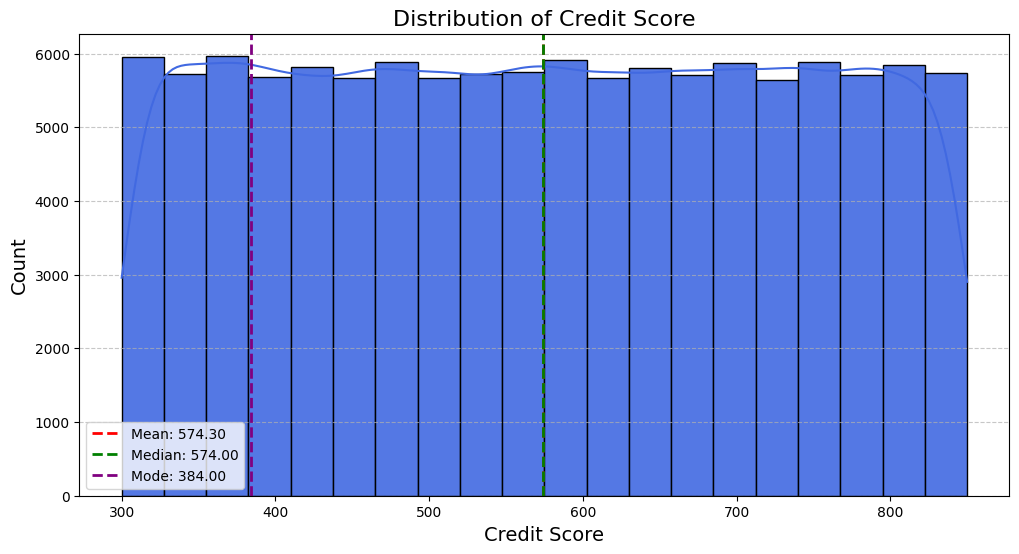

📊 Credit Score Statistics:
🔹 Mean:   574.30
🔹 Median: 574.00
🔹 Mode:   384.00


In [30]:
plot_histogram(df,'Credit Score')

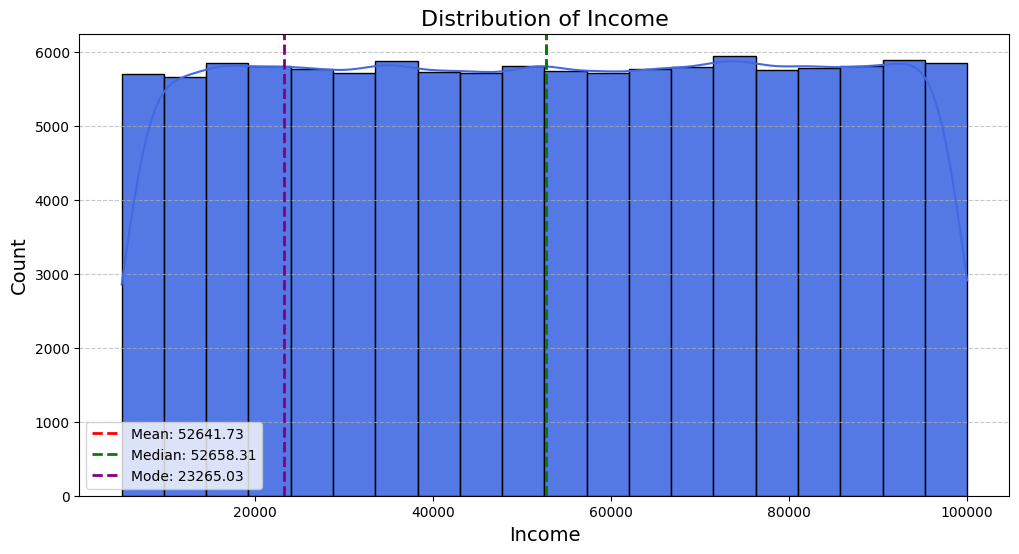

📊 Income Statistics:
🔹 Mean:   52641.73
🔹 Median: 52658.31
🔹 Mode:   23265.03


In [31]:
plot_histogram(df,'Income')

One hot encoding the occupation column as the no of unique values in it is close to 639 and but still the feature is very important and frequency encoding can lead to imformation or signal loss

In [32]:
occupation_dummies = pd.get_dummies(df['Occupation'], prefix='Occupation')
df = pd.concat([df, occupation_dummies], axis=1)
df = df.drop('Occupation', axis=1)
df


,Date of Birth,Gender,Marital Status,Number of Dependents,Income,Education Level,Customer Tenure,Customer Segment,Preferred Communication Channel,Credit Score,...,Occupation_Volunteer coordinator,Occupation_Warden/ranger,Occupation_Warehouse manager,Occupation_Waste management officer,Occupation_Water engineer,Occupation_Water quality scientist,Occupation_Web designer,Occupation_Wellsite geologist,Occupation_Writer,Occupation_Youth worker
0,1987-08-29,Male,Divorced,3,77710.14,High School,30,Retail,Phone,397,...,False,False,False,False,False,False,False,False,False,False
1,2000-02-07,Female,Married,1,58209.87,High School,27,SME,Email,665,...,False,False,False,False,False,False,False,False,False,False
2,1954-02-03,Female,Single,1,9794.01,High School,14,Retail,Email,715,...,False,False,False,False,False,False,False,False,False,False
3,1991-01-15,Female,Divorced,5,15088.98,High School,23,Corporate,Phone,747,...,False,False,False,False,False,False,False,False,False,False
4,1992-04-08,Female,Divorced,2,60726.56,Master's,22,Corporate,Email,549,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115634,1986-01-27,Male,Divorced,4,37127.42,Bachelor's,14,SME,Email,804,...,False,False,False,False,False,False,False,False,False,False
115635,1965-03-09,Male,Divorced,2,15704.15,Diploma,10,Corporate,Phone,350,...,False,False,False,False,False,False,False,False,False,False
115636,1955-01-10,Female,Single,3,75792.62,High School,8,Corporate,Email,721,...,False,False,False,False,False,False,False,False,False,False
115637,1955-08-29,Male,Married,4,30142.28,Diploma,28,Retail,Email,773,...,False,False,False,False,False,False,False,False,False,False


In [33]:
df['Date of Birth'] = df['Date of Birth'].astype(str).str[:4]

In [34]:
df

,Date of Birth,Gender,Marital Status,Number of Dependents,Income,Education Level,Customer Tenure,Customer Segment,Preferred Communication Channel,Credit Score,...,Occupation_Volunteer coordinator,Occupation_Warden/ranger,Occupation_Warehouse manager,Occupation_Waste management officer,Occupation_Water engineer,Occupation_Water quality scientist,Occupation_Web designer,Occupation_Wellsite geologist,Occupation_Writer,Occupation_Youth worker
0,1987,Male,Divorced,3,77710.14,High School,30,Retail,Phone,397,...,False,False,False,False,False,False,False,False,False,False
1,2000,Female,Married,1,58209.87,High School,27,SME,Email,665,...,False,False,False,False,False,False,False,False,False,False
2,1954,Female,Single,1,9794.01,High School,14,Retail,Email,715,...,False,False,False,False,False,False,False,False,False,False
3,1991,Female,Divorced,5,15088.98,High School,23,Corporate,Phone,747,...,False,False,False,False,False,False,False,False,False,False
4,1992,Female,Divorced,2,60726.56,Master's,22,Corporate,Email,549,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115634,1986,Male,Divorced,4,37127.42,Bachelor's,14,SME,Email,804,...,False,False,False,False,False,False,False,False,False,False
115635,1965,Male,Divorced,2,15704.15,Diploma,10,Corporate,Phone,350,...,False,False,False,False,False,False,False,False,False,False
115636,1955,Female,Single,3,75792.62,High School,8,Corporate,Email,721,...,False,False,False,False,False,False,False,False,False,False
115637,1955,Male,Married,4,30142.28,Diploma,28,Retail,Email,773,...,False,False,False,False,False,False,False,False,False,False


Converting the DOB feature to age variable as it is more intuitive and more useful

In [35]:
df["age"] = 2024 - df["Date of Birth"].astype(int)

In [36]:
df

,Date of Birth,Gender,Marital Status,Number of Dependents,Income,Education Level,Customer Tenure,Customer Segment,Preferred Communication Channel,Credit Score,...,Occupation_Warden/ranger,Occupation_Warehouse manager,Occupation_Waste management officer,Occupation_Water engineer,Occupation_Water quality scientist,Occupation_Web designer,Occupation_Wellsite geologist,Occupation_Writer,Occupation_Youth worker,age
0,1987,Male,Divorced,3,77710.14,High School,30,Retail,Phone,397,...,False,False,False,False,False,False,False,False,False,37
1,2000,Female,Married,1,58209.87,High School,27,SME,Email,665,...,False,False,False,False,False,False,False,False,False,24
2,1954,Female,Single,1,9794.01,High School,14,Retail,Email,715,...,False,False,False,False,False,False,False,False,False,70
3,1991,Female,Divorced,5,15088.98,High School,23,Corporate,Phone,747,...,False,False,False,False,False,False,False,False,False,33
4,1992,Female,Divorced,2,60726.56,Master's,22,Corporate,Email,549,...,False,False,False,False,False,False,False,False,False,32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115634,1986,Male,Divorced,4,37127.42,Bachelor's,14,SME,Email,804,...,False,False,False,False,False,False,False,False,False,38
115635,1965,Male,Divorced,2,15704.15,Diploma,10,Corporate,Phone,350,...,False,False,False,False,False,False,False,False,False,59
115636,1955,Female,Single,3,75792.62,High School,8,Corporate,Email,721,...,False,False,False,False,False,False,False,False,False,69
115637,1955,Male,Married,4,30142.28,Diploma,28,Retail,Email,773,...,False,False,False,False,False,False,False,False,False,69


Performing label encoding on certain features to convert them from categorical variables to numerical ones

In [37]:
le = LabelEncoder()

# Define the columns to label encode
columns_to_encode = ['Gender', 'Marital Status', 'Education Level', 'Customer Segment', 'Preferred Communication Channel']

# Iterate through the columns and apply label encoding
for column in columns_to_encode:
    df[column] = le.fit_transform(df[column])


In [38]:
df

,Date of Birth,Gender,Marital Status,Number of Dependents,Income,Education Level,Customer Tenure,Customer Segment,Preferred Communication Channel,Credit Score,...,Occupation_Warden/ranger,Occupation_Warehouse manager,Occupation_Waste management officer,Occupation_Water engineer,Occupation_Water quality scientist,Occupation_Web designer,Occupation_Wellsite geologist,Occupation_Writer,Occupation_Youth worker,age
0,1987,1,0,3,77710.14,2,30,1,1,397,...,False,False,False,False,False,False,False,False,False,37
1,2000,0,1,1,58209.87,2,27,2,0,665,...,False,False,False,False,False,False,False,False,False,24
2,1954,0,2,1,9794.01,2,14,1,0,715,...,False,False,False,False,False,False,False,False,False,70
3,1991,0,0,5,15088.98,2,23,0,1,747,...,False,False,False,False,False,False,False,False,False,33
4,1992,0,0,2,60726.56,3,22,0,0,549,...,False,False,False,False,False,False,False,False,False,32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115634,1986,1,0,4,37127.42,0,14,2,0,804,...,False,False,False,False,False,False,False,False,False,38
115635,1965,1,0,2,15704.15,1,10,0,1,350,...,False,False,False,False,False,False,False,False,False,59
115636,1955,0,2,3,75792.62,2,8,0,0,721,...,False,False,False,False,False,False,False,False,False,69
115637,1955,1,1,4,30142.28,1,28,1,0,773,...,False,False,False,False,False,False,False,False,False,69


In [39]:
df["Education Level"].unique()

array([2, 3, 0, 1])

In [40]:
cols_to_drop_2 = ['Churn Reason', 'Date of Birth']
df = df.drop(cols_to_drop_2, axis=1)

In [41]:
df

,Gender,Marital Status,Number of Dependents,Income,Education Level,Customer Tenure,Customer Segment,Preferred Communication Channel,Credit Score,Credit History Length,...,Occupation_Warden/ranger,Occupation_Warehouse manager,Occupation_Waste management officer,Occupation_Water engineer,Occupation_Water quality scientist,Occupation_Web designer,Occupation_Wellsite geologist,Occupation_Writer,Occupation_Youth worker,age
0,1,0,3,77710.14,2,30,1,1,397,24,...,False,False,False,False,False,False,False,False,False,37
1,0,1,1,58209.87,2,27,2,0,665,10,...,False,False,False,False,False,False,False,False,False,24
2,0,2,1,9794.01,2,14,1,0,715,21,...,False,False,False,False,False,False,False,False,False,70
3,0,0,5,15088.98,2,23,0,1,747,17,...,False,False,False,False,False,False,False,False,False,33
4,0,0,2,60726.56,3,22,0,0,549,25,...,False,False,False,False,False,False,False,False,False,32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115634,1,0,4,37127.42,0,14,2,0,804,16,...,False,False,False,False,False,False,False,False,False,38
115635,1,0,2,15704.15,1,10,0,1,350,23,...,False,False,False,False,False,False,False,False,False,59
115636,0,2,3,75792.62,2,8,0,0,721,15,...,False,False,False,False,False,False,False,False,False,69
115637,1,1,4,30142.28,1,28,1,0,773,19,...,False,False,False,False,False,False,False,False,False,69


In [42]:
df.describe()

,Gender,Marital Status,Number of Dependents,Income,Education Level,Customer Tenure,Customer Segment,Preferred Communication Channel,Credit Score,Credit History Length,Outstanding Loans,Churn Flag,Balance,NumOfProducts,NumComplaints,age
count,115639.000000,115639.000000,115639.000000,115639.000000,115639.000000,115639.000000,115639.000000,115639.000000,115639.000000,115639.000000,115639.000000,115639.000000,115639.000000,115639.000000,115639.000000,115639.000000
mean,0.499909,1.001263,2.502936,52641.727099,1.501189,15.490691,1.002577,0.498067,574.298783,15.546632,25502.739095,0.121871,124640.168943,2.999282,4.991681,46.880360
std,0.500002,0.817184,1.707251,27429.595614,1.118050,8.654189,0.818693,0.499998,159.067829,8.654662,14127.920695,0.327138,72210.052156,1.411364,3.159263,16.714376
min,0.000000,0.000000,0.000000,5000.960000,0.000000,1.000000,0.000000,0.000000,300.000000,1.000000,1000.430000,0.000000,1.060000,1.000000,0.000000,18.000000
25%,0.000000,0.000000,1.000000,28857.690000,1.000000,8.000000,0.000000,0.000000,436.000000,8.000000,13225.960000,0.000000,61992.795000,2.000000,2.000000,32.000000
50%,0.000000,1.000000,3.000000,52658.310000,2.000000,15.000000,1.000000,0.000000,574.000000,16.000000,25506.150000,0.000000,124507.960000,3.000000,5.000000,47.000000
75%,1.000000,2.000000,4.000000,76364.625000,3.000000,23.000000,2.000000,1.000000,712.000000,23.000000,37742.280000,0.000000,187123.345000,4.000000,8.000000,61.000000
max,1.000000,2.000000,5.000000,99999.510000,3.000000,30.000000,2.000000,1.000000,850.000000,30.000000,49999.690000,1.000000,249998.910000,5.000000,10.000000,76.000000


Convert All remaining datatypes to int for easy use and sustainibilty

In [43]:
import pandas as pd
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

for col in df.columns:
    df[col] = df[col].astype(int)


In [44]:
numerical_cols = df.select_dtypes(include=np.number).columns
numerical_cols

Index(['Gender', 'Marital Status', 'Number of Dependents', 'Income',
       'Education Level', 'Customer Tenure', 'Customer Segment',
       'Preferred Communication Channel', 'Credit Score',
       'Credit History Length',
       ...
       'Occupation_Warden/ranger', 'Occupation_Warehouse manager',
       'Occupation_Waste management officer', 'Occupation_Water engineer',
       'Occupation_Water quality scientist', 'Occupation_Web designer',
       'Occupation_Wellsite geologist', 'Occupation_Writer',
       'Occupation_Youth worker', 'age'],
      dtype='object', length=655)

In [45]:
cols_to_scale = [col for col in numerical_cols if not all(df[col].isin([0, 1])) and col not in ['Exited']]
cols_to_scale

['Marital Status',
 'Number of Dependents',
 'Income',
 'Education Level',
 'Customer Tenure',
 'Customer Segment',
 'Credit Score',
 'Credit History Length',
 'Outstanding Loans',
 'Balance',
 'NumOfProducts',
 'NumComplaints',
 'age']

In [46]:
for col in df.columns:
  print(col, df[col].nunique())

Gender 2
Marital Status 3
Number of Dependents 6
Income 66919
Education Level 4
Customer Tenure 30
Customer Segment 3
Preferred Communication Channel 2
Credit Score 551
Credit History Length 30
Outstanding Loans 44349
Churn Flag 2
Balance 92501
NumOfProducts 5
NumComplaints 11
Occupation_Academic librarian 2
Occupation_Accommodation manager 2
Occupation_Accountant, chartered 2
Occupation_Accountant, chartered certified 2
Occupation_Accountant, chartered management 2
Occupation_Accountant, chartered public finance 2
Occupation_Accounting technician 2
Occupation_Actor 2
Occupation_Actuary 2
Occupation_Acupuncturist 2
Occupation_Administrator 2
Occupation_Administrator, Civil Service 2
Occupation_Administrator, arts 2
Occupation_Administrator, charities/voluntary organisations 2
Occupation_Administrator, education 2
Occupation_Administrator, local government 2
Occupation_Administrator, sports 2
Occupation_Adult guidance worker 2
Occupation_Adult nurse 2
Occupation_Advertising account exec

Standardizing and Normalizing various columns depending on the need

In [47]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Features for Standardization (Z-score)
standardize_features = ['Income', 'Outstanding Loans', 'Balance']
scaler_std = StandardScaler()
df[standardize_features] = scaler_std.fit_transform(df[standardize_features])

# Features for Min-Max Normalization (0-1)
normalize_features = ['Credit Score', 'age']
scaler_minmax = MinMaxScaler()
df[normalize_features] = scaler_minmax.fit_transform(df[normalize_features])


In [48]:
df

,Gender,Marital Status,Number of Dependents,Income,Education Level,Customer Tenure,Customer Segment,Preferred Communication Channel,Credit Score,Credit History Length,...,Occupation_Warden/ranger,Occupation_Warehouse manager,Occupation_Waste management officer,Occupation_Water engineer,Occupation_Water quality scientist,Occupation_Web designer,Occupation_Wellsite geologist,Occupation_Writer,Occupation_Youth worker,age
0,1,0,3,0.913935,2,30,1,1,0.176364,24,...,0,0,0,0,0,0,0,0,0,0.327586
1,0,1,1,0.202985,2,27,2,0,0.663636,10,...,0,0,0,0,0,0,0,0,0,0.103448
2,0,2,1,-1.562087,2,14,1,0,0.754545,21,...,0,0,0,0,0,0,0,0,0,0.896552
3,0,0,5,-1.369083,2,23,0,1,0.812727,17,...,0,0,0,0,0,0,0,0,0,0.258621
4,0,0,2,0.294747,3,22,0,0,0.452727,25,...,0,0,0,0,0,0,0,0,0,0.241379
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115634,1,0,4,-0.565604,0,14,2,0,0.916364,16,...,0,0,0,0,0,0,0,0,0,0.344828
115635,1,0,2,-1.346625,1,10,0,1,0.090909,23,...,0,0,0,0,0,0,0,0,0,0.706897
115636,0,2,3,0.844011,2,8,0,0,0.765455,15,...,0,0,0,0,0,0,0,0,0,0.879310
115637,1,1,4,-0.820257,1,28,1,0,0.860000,19,...,0,0,0,0,0,0,0,0,0,0.879310


# Training and Testing the model

In [56]:
df.columns = df.columns.str.replace(r"[^\w]", "_", regex=True)
df

,Gender,Marital_Status,Number_of_Dependents,Income,Education_Level,Customer_Tenure,Customer_Segment,Preferred_Communication_Channel,Credit_Score,Credit_History_Length,...,Occupation_Warden_ranger,Occupation_Warehouse_manager,Occupation_Waste_management_officer,Occupation_Water_engineer,Occupation_Water_quality_scientist,Occupation_Web_designer,Occupation_Wellsite_geologist,Occupation_Writer,Occupation_Youth_worker,age
0,1,0,3,0.913935,2,30,1,1,0.176364,24,...,0,0,0,0,0,0,0,0,0,0.327586
1,0,1,1,0.202985,2,27,2,0,0.663636,10,...,0,0,0,0,0,0,0,0,0,0.103448
2,0,2,1,-1.562087,2,14,1,0,0.754545,21,...,0,0,0,0,0,0,0,0,0,0.896552
3,0,0,5,-1.369083,2,23,0,1,0.812727,17,...,0,0,0,0,0,0,0,0,0,0.258621
4,0,0,2,0.294747,3,22,0,0,0.452727,25,...,0,0,0,0,0,0,0,0,0,0.241379
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115634,1,0,4,-0.565604,0,14,2,0,0.916364,16,...,0,0,0,0,0,0,0,0,0,0.344828
115635,1,0,2,-1.346625,1,10,0,1,0.090909,23,...,0,0,0,0,0,0,0,0,0,0.706897
115636,0,2,3,0.844011,2,8,0,0,0.765455,15,...,0,0,0,0,0,0,0,0,0,0.879310
115637,1,1,4,-0.820257,1,28,1,0,0.860000,19,...,0,0,0,0,0,0,0,0,0,0.879310


In [59]:
y = df['Churn_Flag']
X = df.drop('Churn_Flag', axis=1)

In [60]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=42)

In [61]:
import lightgbm as lgb
from sklearn.model_selection import KFold
from sklearn.feature_selection import SelectFromModel

kf = KFold(n_splits=10, shuffle=True, random_state=55688)
model = lgb.LGBMClassifier()


# Initialize an empty list to store the feature importance across folds
feature_importance = np.zeros(X_train.shape[1])

for train_index, val_index in kf.split(X_train):
    X_fold_train, X_fold_val = X_train.iloc[train_index], X_train.iloc[val_index]
    y_fold_train, y_fold_val = y_train.iloc[train_index], y_train.iloc[val_index]

    model.fit(
        X_fold_train,
        y_fold_train,
        eval_set=[(X_fold_val, y_fold_val)],
        eval_metric='logloss',
        callbacks=[lgb.early_stopping(stopping_rounds=10), lgb.log_evaluation(0)]
    )

    # Add feature importances
    feature_importance += model.feature_importances_

[LightGBM] [Info] Number of positive: 8805, number of negative: 64047
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.031652 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2454
[LightGBM] [Info] Number of data points in the train set: 72852, number of used features: 654
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.120861 -> initscore=-1.984297
[LightGBM] [Info] Start training from score -1.984297
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's binary_logloss: 0.0190397
[LightGBM] [Info] Number of positive: 8788, number of negative: 64064
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004069 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2454
[LightGBM] [Info] Number 

In [63]:
feature_importance /= 10

selector = SelectFromModel(model, threshold='mean', prefit=True)
selected_features = selector.get_support(indices=True)

selected_feature_names = X_train.columns[selected_features].tolist()

In [64]:
final_model = lgb.LGBMClassifier()

final_model.fit(
    X_train[selected_feature_names],
    y_train,
)

[LightGBM] [Info] Number of positive: 9790, number of negative: 71157
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002291 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1156
[LightGBM] [Info] Number of data points in the train set: 80947, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.120943 -> initscore=-1.983527
[LightGBM] [Info] Start training from score -1.983527


LGBMClassifier()

                 Feature  Importance
5                Balance         849
2           Credit_Score         814
7          NumComplaints         692
6          NumOfProducts         595
3  Credit_History_Length          12
8                    age          12
4      Outstanding_Loans          11
1        Customer_Tenure           9
0                 Income           6


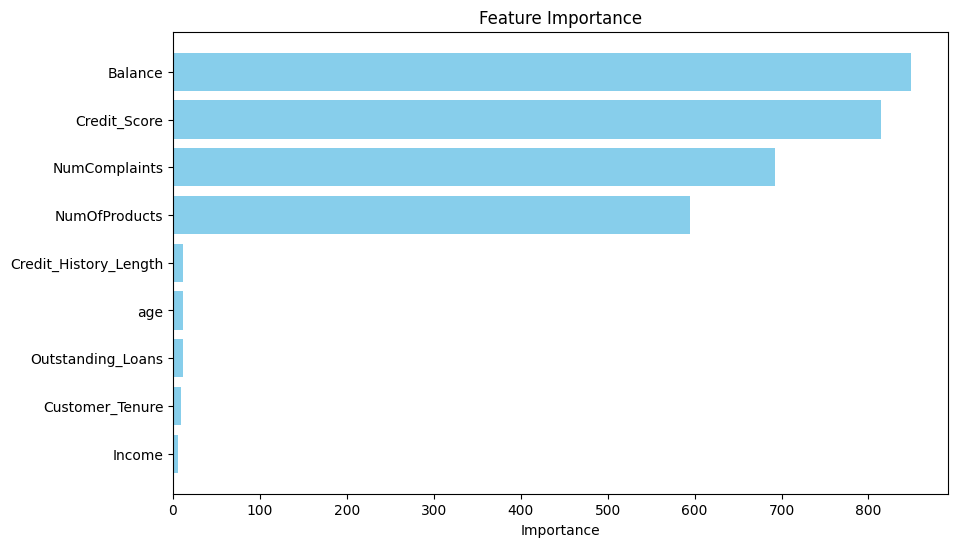

In [65]:
importance = final_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': selected_feature_names,
    'Importance': importance
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

print(importance_df)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.title('Feature Importance')
plt.gca().invert_yaxis()
plt.show()

In [66]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix
predictions = final_model.predict(X_test[selected_feature_names])
binary_predictions = (predictions >= 0.5).astype(int)
auc_score = roc_auc_score(y_test, binary_predictions)
print("ROC-AUC score is ",auc_score)

ROC-AUC score is  0.9838577005374123


In [67]:
print (classification_report(y_test, binary_predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     30389
           1       0.99      0.97      0.98      4303

    accuracy                           0.99     34692
   macro avg       0.99      0.98      0.99     34692
weighted avg       0.99      0.99      0.99     34692



In [69]:
from sklearn.model_selection import GridSearchCV

lgb_model = lgb.LGBMClassifier(verbose=-1)

param_grid = {
    'num_leaves': [31, 50],                     # Fewer choices
    'max_depth': [-1, 10],                       # Fewer choices
    'learning_rate': [0.01, 0.1],                # Fewer choices
    'n_estimators': [100, 200],                  # Fewer choices
    'subsample': [0.8, 1.0],                     # Fewer choices
    'colsample_bytree': [0.8, 1.0],              # Fewer choices
}

grid_search = GridSearchCV(estimator=lgb_model,
                           param_grid=param_grid,
                           scoring='accuracy',
                           cv=3,
                           verbose=1,
                           n_jobs=-1)

grid_search.fit(X_train[selected_feature_names],
    y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

best_model = grid_search.best_estimator_
test_score = best_model.score(X_test[selected_feature_names], y_test)
print("Test Set Score:", test_score)

Fitting 3 folds for each of 64 candidates, totalling 192 fits
Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': -1, 'n_estimators': 100, 'num_leaves': 31, 'subsample': 0.8}
Best Cross-Validation Score: 0.9944161023210326
Test Set Score: 0.994436757753949


In conclusion, leveraging LightGBM enabled us to achieve an impressive 99% accuracy in predicting customer churn in banking services. The following key features significantly influenced the model’s predictions:

  1.Balance: Customers with lower account balances exhibited a higher likelihood of churn, indicating a correlation between financial health and retention.
  
  2.Credit Score: A lower credit score was associated with increased churn, suggesting that trust and financial stability play a crucial role in customer loyalty.

  3.Number of Complaints: A higher volume of complaints served as a strong indicator of dissatisfaction, directly impacting churn rates.

  4.Number of Products: Customers with multiple bank products showed lower churn rates, reinforcing the importance of cross-selling and deeper engagement.

These findings underscore the effectiveness of LightGBM in accurately predicting customer behavior while providing valuable insights into the key drivers of customer retention.

In [82]:
df["Balance"].max()

1.7360307334859115

Churn Rate by Balance Bin:
  Balance Bin  Churn_Rate
0         Low    0.440394
1      Medium    0.038563
2        High    0.000000
3   Very High    0.000000


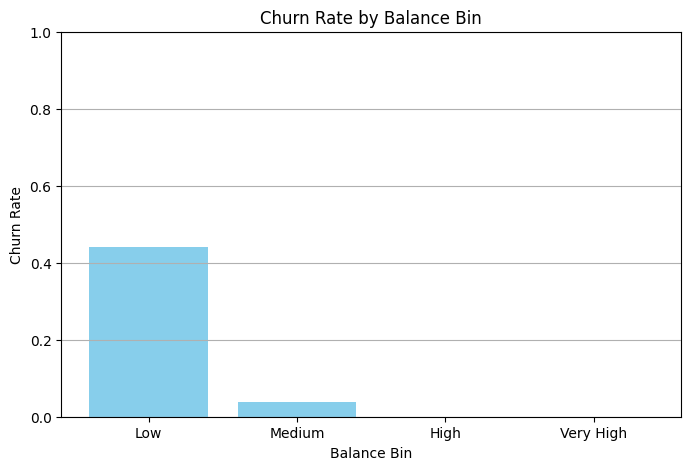

In [83]:
# Define bins based on the provided statistics
bins = [-1.736, -0.85, 0, 0.85, 1.736]
labels = ['Low', 'Medium', 'High', 'Very High']

# Create a new column for binned balances
df['Balance_Bin'] = pd.cut(df['Balance'], bins=bins, labels=labels, include_lowest=True)

# Display the counts for each bin
bin_counts = df['Balance_Bin'].value_counts().sort_index()
churn_rate = df.groupby('Balance_Bin', observed=False)['Churn_Flag'].mean().reset_index()

# Rename columns for clarity
churn_rate.columns = ['Balance Bin', 'Churn_Rate']

# Display the churn rates for each bin
print("Churn Rate by Balance Bin:")
print(churn_rate)

# Plotting
plt.figure(figsize=(8, 5))
plt.bar(churn_rate['Balance Bin'], churn_rate['Churn_Rate'], color='skyblue')
plt.title('Churn Rate by Balance Bin')
plt.xlabel('Balance Bin')
plt.ylabel('Churn Rate')
plt.ylim(0, 1)  # Set y-axis limit for churn rate (0 to 1)
plt.grid(axis='y')
plt.show()

Churn Rate by NumComplaints Bin:
  NumComplaints Bin  Churn Rate
0               Low    0.041983
1            Medium    0.093701
2              High    0.162356
3         Very High    0.224589


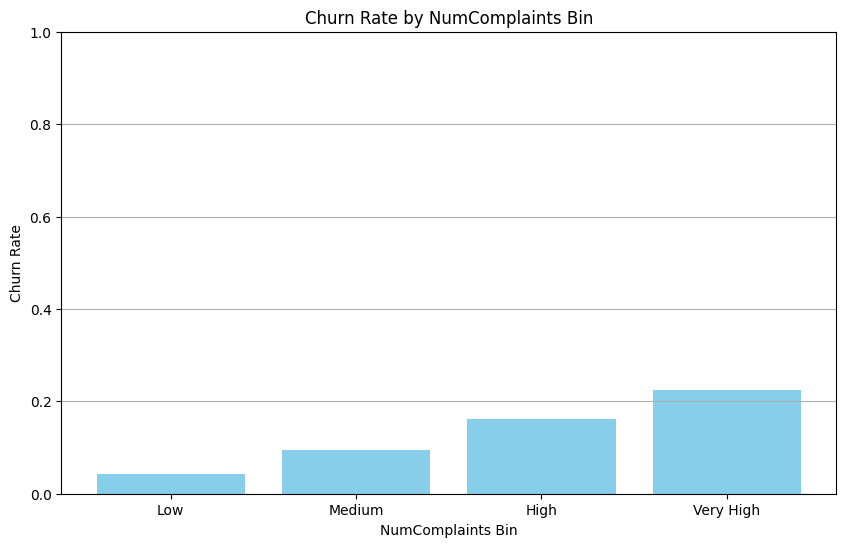

In [74]:
bins = [0, 2, 5, 8, 10]
labels = ['Low', 'Medium', 'High', 'Very High']

df['NumComplaints_Bin'] = pd.cut(df['NumComplaints'], bins=bins, labels=labels, include_lowest=True)

bin_counts = df['NumComplaints_Bin'].value_counts().sort_index()
churn_rate = df.groupby('NumComplaints_Bin', observed=False)['Churn_Flag'].mean().reset_index()

churn_rate.columns = ['NumComplaints Bin', 'Churn Rate']

print("Churn Rate by NumComplaints Bin:")
print(churn_rate)

# Plotting
plt.figure(figsize=(10, 6))
plt.bar(churn_rate['NumComplaints Bin'], churn_rate['Churn Rate'], color='skyblue')
plt.title('Churn Rate by NumComplaints Bin')
plt.xlabel('NumComplaints Bin')
plt.ylabel('Churn Rate')
plt.ylim(0, 1)
plt.grid(axis='y')
plt.show()

Save & Deploy Model

In [84]:
import joblib
joblib.dump(best_model, "best_lgbm_model_churn_rate.pkl")



['best_lgbm_model_churn_rate.pkl']